### Churn Analysis for Fit.Ly

## Introduction

Fit.ly is a subscription-based fitness app offering workout articles, instructional videos, workout tracking, and the ability to share workouts. Over the past two quarters, Fit.ly has seen customer churn rise, putting pressure on acquisition costs and on the Product and Marketing teams. I was asked to identify what's driving churn and provide practical recommendations leadership can act on next quarter.

I was provided three datasets for this analysis:
1. Account information (400 customers)
2. Customer support tickets
3. User activity logs

All three were validated and cleaned before analysis to ensure consistent identifiers, correct data types, and reliable values — detailed below.

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

acc = pd.read_csv('da_fitly_account_info.csv')
sup = pd.read_csv('da_fitly_customer_support.csv')
act = pd.read_csv('da_fitly_user_activity.csv')

acc['churned'] = acc['churn_status'].eq('Y')
acc['customer_num'] = acc['customer_id'].str.replace('C', '', regex=False).astype(int)
sup['ticket_time'] = pd.to_datetime(sup['ticket_time'])
act['event_time'] = pd.to_datetime(act['event_time'])

activity_count = act.groupby('user_id').size().rename('activity_count')
ticket_count = sup.groupby('user_id').size().rename('ticket_count')
avg_resolution = sup.groupby('user_id').resolution_time_hours.mean().rename('avg_resolution_hrs')

df = (acc.merge(activity_count, left_on='customer_num', right_index=True, how='left')
         .merge(ticket_count, left_on='customer_num', right_index=True, how='left')
         .merge(avg_resolution, left_on='customer_num', right_index=True, how='left'))
df['activity_count'] = df['activity_count'].fillna(0)
df['ticket_count'] = df['ticket_count'].fillna(0)
df['eng_bucket'] = pd.cut(df.activity_count, bins=[-1,0,2,5,100], labels=['0 events','1-2 events','3-5 events','6+ events'])

## Data Validation

Every column across the three sources was checked for missing values, duplicates, and consistency with what Product and Engineering described.

**account_info**
- `customer_id`, `email` — 0% missing, 0 duplicates
- `state` — 0% missing, 50 valid US state names
- `plan` — 0% missing, 4 clean tiers (Free/Basic/Pro/Enterprise)
- `plan_list_price` — 0% missing, consistent non-overlapping ranges per tier
- `churn_status` — 71.5% blank / 28.5% "Y". Per Product, blanks mean active (not missing) — recoded to boolean `churned`
- `signup_date` — described by Product but **does not exist** in the file provided; flagged for Engineering to confirm

**customer_support**
- `ticket_time`, `user_id` — 0% missing, all user_ids match account_info
- `channel` — 4.2% contain "-" instead of chat/phone/email; treated as "Unknown" rather than dropped
- `topic`, `resolution_time_hours` — clean, no missing or invalid values
- `state` — only contains 0/1, undocumented, unrelated to churn (30.4% either way) — **excluded from analysis**, flagged for the source team
- `comments` — 95% blank as expected; 36 non-blank rows are GDPR data-deletion requests, routed separately as a compliance item

**user_activity**
- `event_time`, `user_id`, `event_type` — 0% missing, all user_ids match account_info
- 154 of 400 customers (38.5%) have zero logged activity — a real signal, not a data gap

In [29]:
print(acc.isna().sum()); print()
print(sup.isna().sum()); print()
print(act.isna().sum())

customer_id          0
email                0
state                0
plan                 0
plan_list_price      0
churn_status       286
churned              0
customer_num         0
dtype: int64

ticket_time                0
user_id                    0
channel                    0
topic                      0
resolution_time_hours      0
state                      0
comments                 872
dtype: int64

event_time    0
user_id       0
event_type    0
dtype: int64


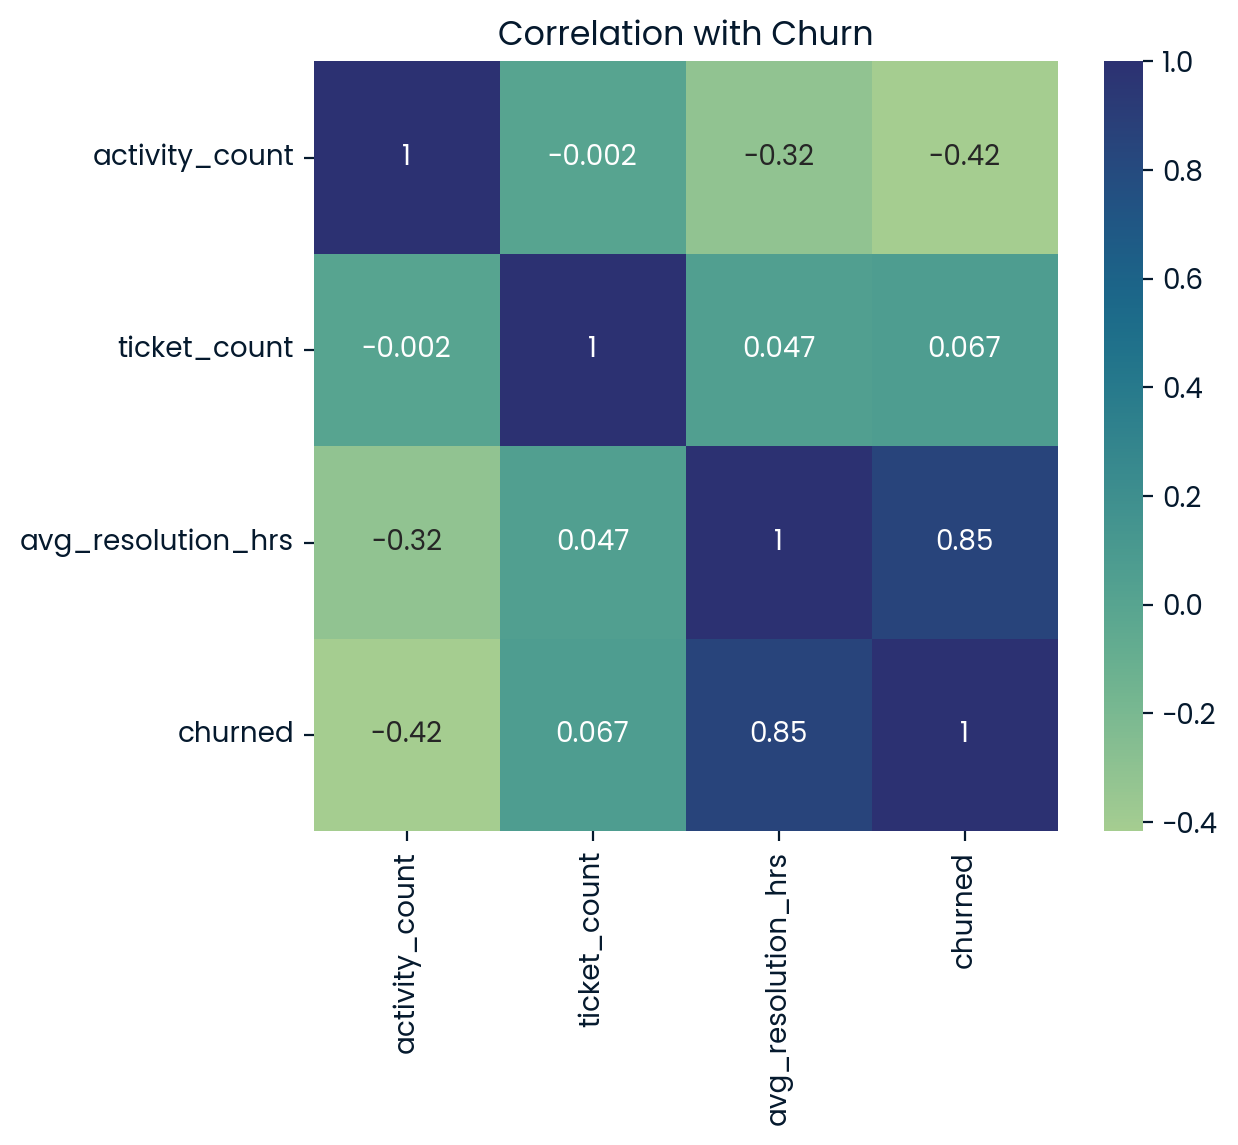

In [30]:
corr_df = df[['activity_count','ticket_count','avg_resolution_hrs','churned']].copy()
corr_df['churned'] = corr_df['churned'].astype(int)
fig, ax = plt.subplots(figsize=(6,5))
sns.heatmap(corr_df.corr(), annot=True, cmap='crest', ax=ax)
ax.set_title('Correlation with Churn')
plt.show()

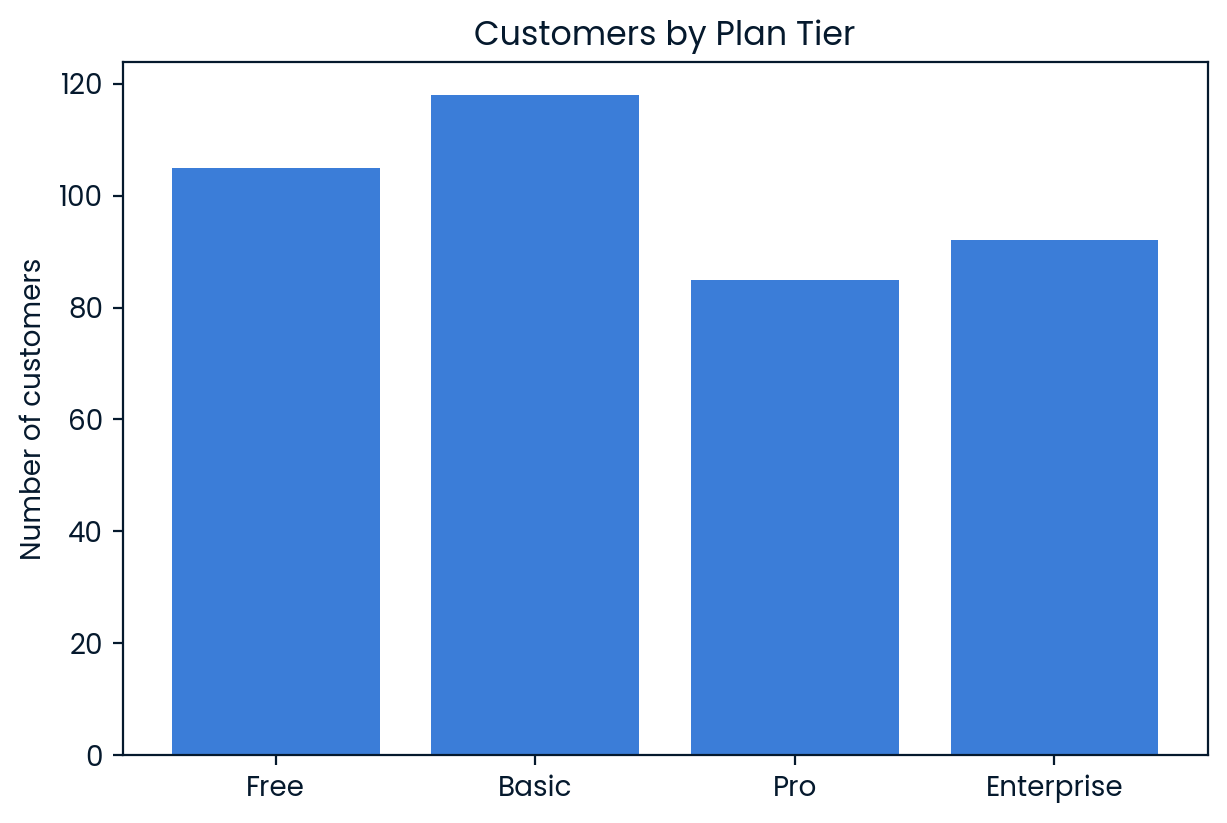

In [31]:
order = ['Free','Basic','Pro','Enterprise']
counts = acc.plan.value_counts().reindex(order)
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(counts.index, counts.values, color='#3B7DD8')
ax.set_title('Customers by Plan Tier'); ax.set_ylabel('Number of customers')
plt.show()

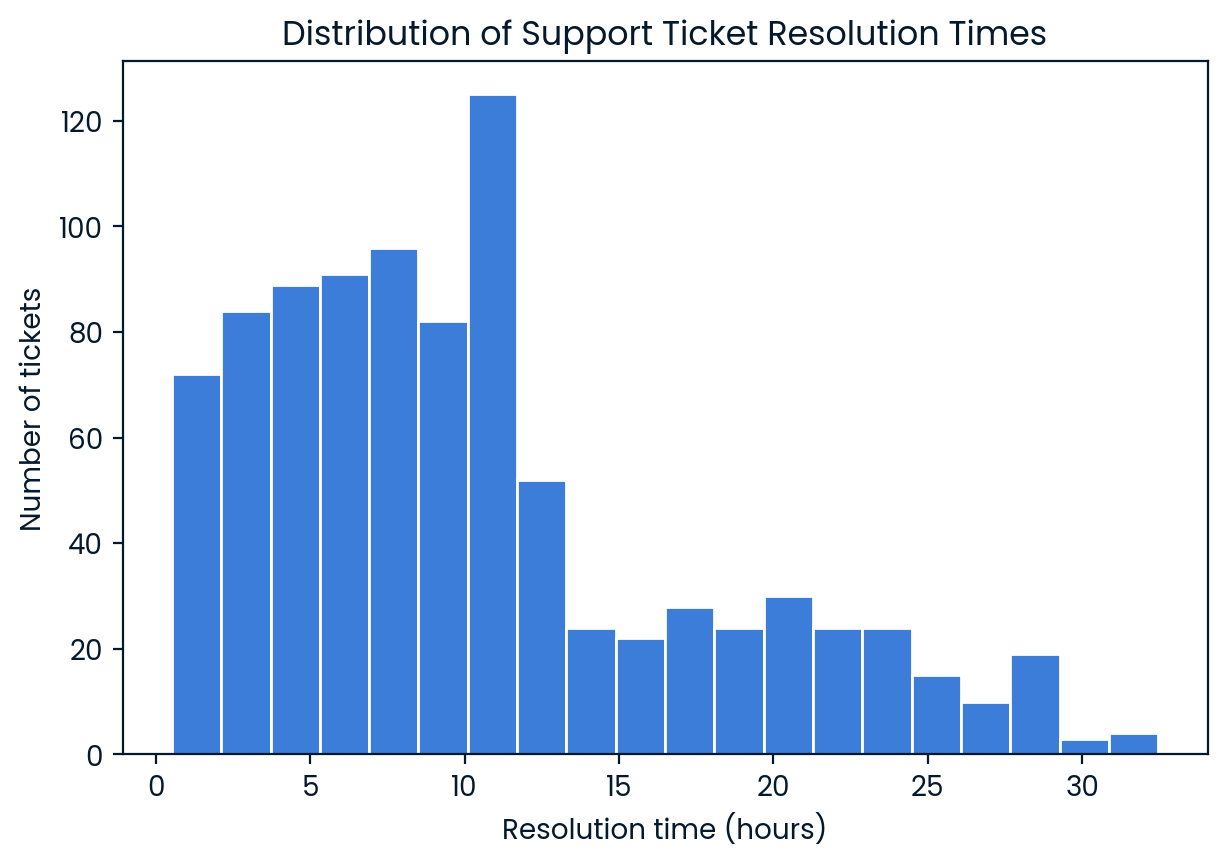

In [32]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.hist(sup.resolution_time_hours, bins=20, color='#3B7DD8', edgecolor='white')
ax.set_title('Distribution of Support Ticket Resolution Times')
ax.set_xlabel('Resolution time (hours)'); ax.set_ylabel('Number of tickets')
plt.show()

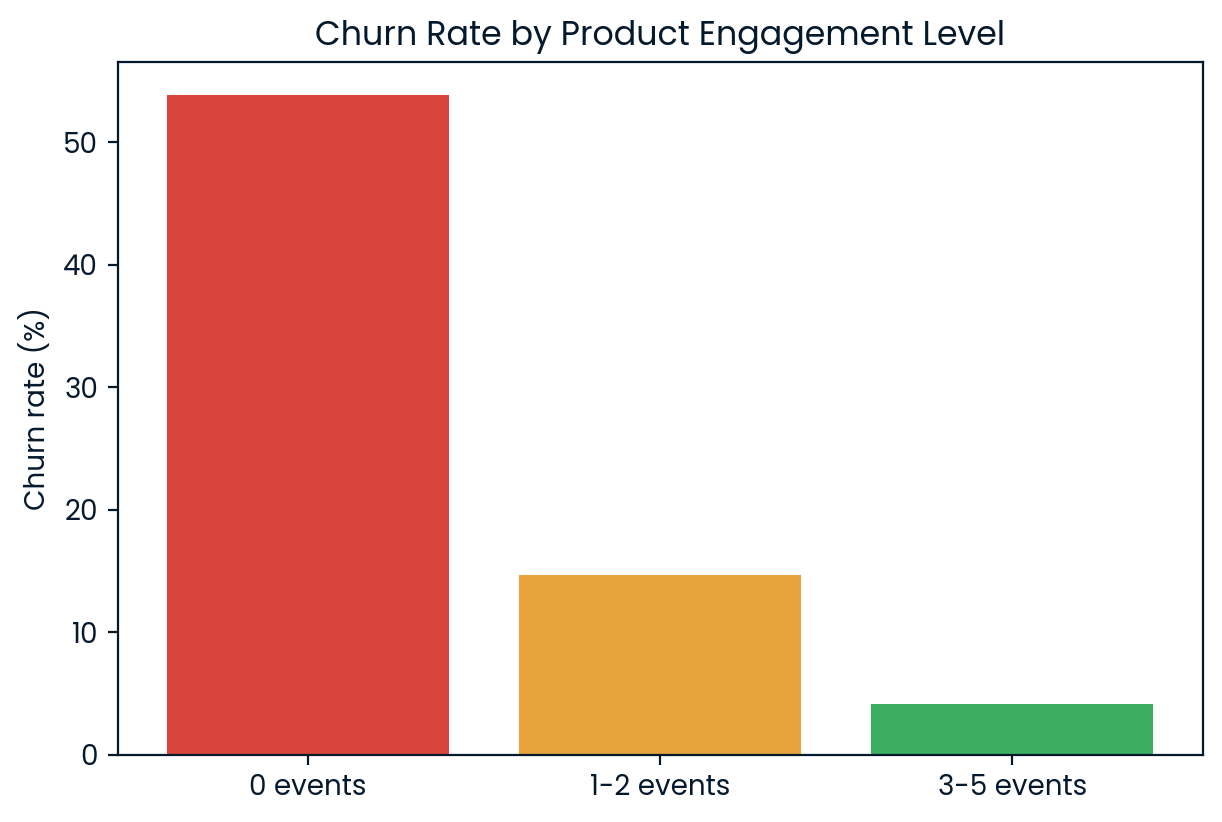

In [33]:
eng_churn = df.groupby('eng_bucket', observed=True).churned.mean().reindex(['0 events','1-2 events','3-5 events']).mul(100)
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(eng_churn.index, eng_churn.values, color=['#D8453B','#E8A33D','#3BAE5F'])
ax.set_title('Churn Rate by Product Engagement Level'); ax.set_ylabel('Churn rate (%)')
plt.show()

This relationship holds even after controlling for engagement: among customers with zero activity, those who churned still waited far longer for support resolution (18.7 hrs) than those who stayed (6.1 hrs) — nearly identical to the gap seen across the full customer base. This confirms resolution time is an independent driver of churn, not simply a byproduct of low engagement.

In [34]:
zero_eng = df[df.activity_count == 0]
print(zero_eng.groupby('churned').avg_resolution_hrs.mean())

churned
False     6.141263
True     18.655108
Name: avg_resolution_hrs, dtype: float64


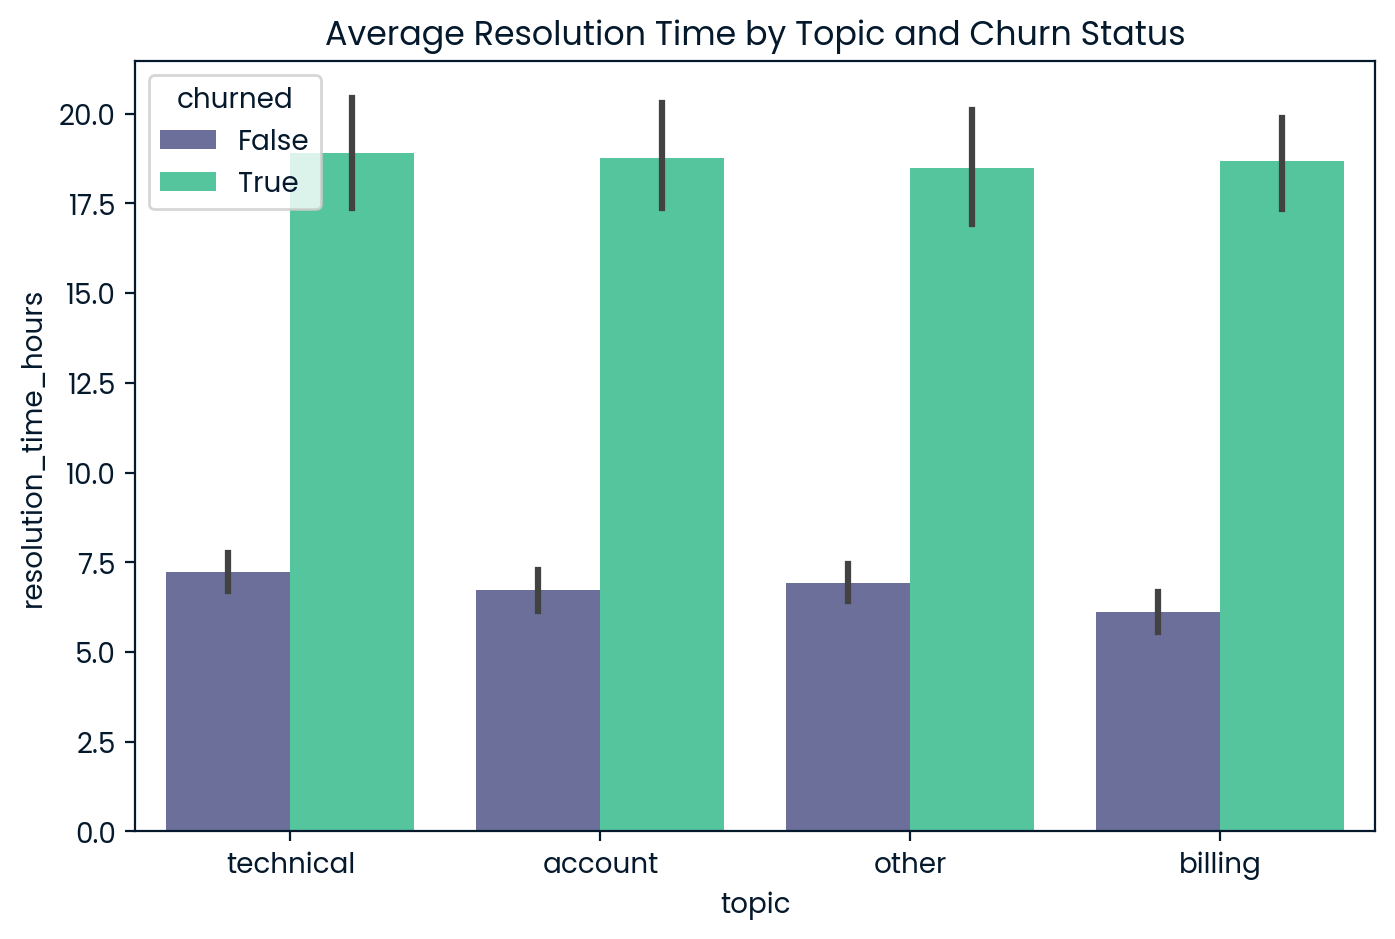

In [35]:

fig, ax = plt.subplots(figsize=(8,5))
sns.barplot(data=sup2, x='topic', y='resolution_time_hours', hue='churned', ax=ax)
ax.set_title('Average Resolution Time by Topic and Churn Status')
plt.show()

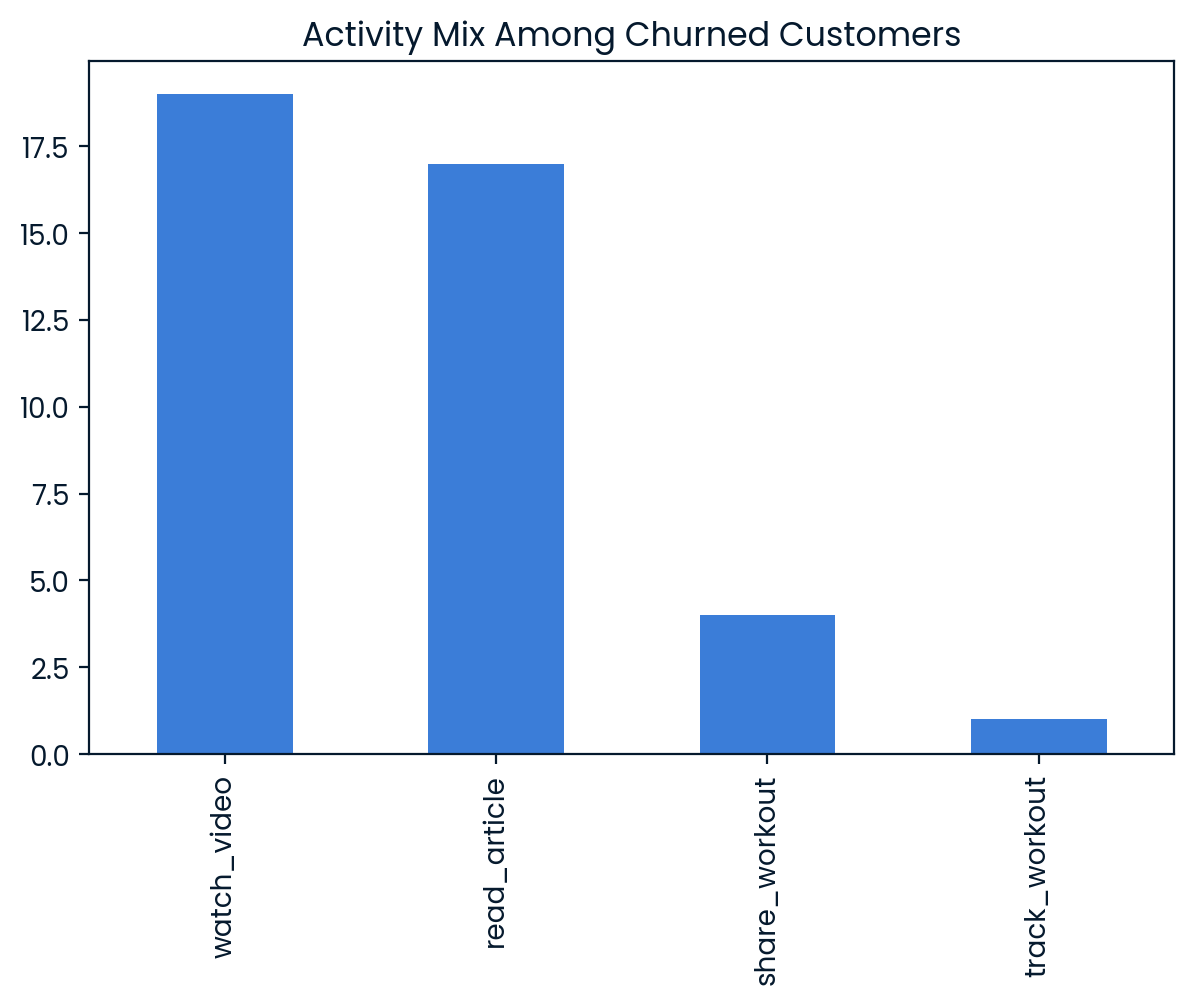

In [36]:
churned_ids = acc.loc[acc.churned, 'customer_num']
churned_events = act[act.user_id.isin(churned_ids)]
fig, ax = plt.subplots(figsize=(7,4.5))
churned_events.event_type.value_counts().plot(kind='bar', ax=ax, color='#3B7DD8')
ax.set_title('Activity Mix Among Churned Customers')
plt.show()

Customers with zero recorded product activity churn at **53.9%** — over 10x the rate of highly engaged customers (**4.2%**), a far wider gap than any split by plan type (22.4%–41.0%). Among ticketed customers, churned customers waited **18.7 hrs** on average for resolution vs **6.7 hrs** for retained ones. Engagement, not plan tier or ticket volume, is the clearest churn signal in this data.

## Metric to Monitor: Customer Engagement Rate

**Definition:** % of customers who log at least one product activity event (video, article, workout tracked/shared) in a period. Engagement is a *leading* indicator, unlike churn itself which only shows up after cancellation.

**How the business should use it:** Track this rate monthly, broken out by plan tier. Because it's a leading indicator, a declining trend is an early warning that should trigger a re-engagement campaign (in-app nudges, email outreach) before those customers reach the point of cancelling — rather than finding out about the problem only after churn has already happened. A useful early-warning threshold would be a month-over-month drop of more than 3-5 percentage points, or any single plan tier falling meaningfully below the 61.5% overall baseline.

In [37]:
engaged = (df.activity_count > 0).sum()
print(f'Engagement Rate baseline: {engaged/len(df)*100:.1f}% ({engaged} of {len(df)} customers)')

Engagement Rate baseline: 61.5% (246 of 400 customers)


In [38]:
sup['day_of_week'] = sup.ticket_time.dt.day_name()
sup['hour'] = sup.ticket_time.dt.hour
sup.groupby('day_of_week').resolution_time_hours.mean().sort_values(ascending=False)

day_of_week
Sunday       11.466642
Tuesday      10.801130
Wednesday    10.789200
Saturday     10.319732
Thursday     10.046950
Friday        9.780000
Monday        9.730385
Name: resolution_time_hours, dtype: float64

 ## Summary & Recommendations

Overall churn is 28.5%. Product engagement is the dominant driver (10x churn gap), support resolution speed is secondary.

1. Launch a re-engagement push for the 38.5% of customers with zero activity
2. Enforce a 10-hour support SLA, prioritizing billing tickets (36.4% churn)
3. Build a Free-tier upgrade path (41.0% churn, highest of any plan)
4. Fix the missing `signup_date` field and the ambiguous `customer_support.state` field
5. Route the 36 GDPR deletion requests to the compliance process